In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Load historical stock prices
prices = pd.read_csv(
    "five_stock_prices.csv",
    index_col=0,
    parse_dates=True
)

prices = prices.sort_index().dropna()

# Calculate daily returns
returns = prices.pct_change().dropna()

# Chronological 70% training / 30% testing split
split = int(len(returns) * 0.70)

train = returns.iloc[:split]
test = returns.iloc[split:]

print("Stocks:", list(returns.columns))
print("Training period:", train.index.min().date(),
      "to", train.index.max().date())
print("Testing period:", test.index.min().date(),
      "to", test.index.max().date())
print("Training days:", len(train))
print("Testing days:", len(test))

assert len(train) > 0 and len(test) > 0
assert train.index.max() < test.index.min()

Stocks: ['AAPL', 'BLK', 'GS', 'JPM', 'MSFT']
Training period: 2025-09-24 to 2026-06-03
Testing period: 2026-06-04 to 2026-09-21
Training days: 174
Testing days: 75


In [2]:


# Estimate annualized covariance using training data only
cov = train.cov().values * 252
assets = list(train.columns)
n = len(assets)

# 1. Equal-weight portfolio
equal_weights = np.ones(n) / n

# 2. Minimum-variance portfolio
def portfolio_volatility(w):
    return np.sqrt(w @ cov @ w)

constraints = {"type": "eq", "fun": lambda w: w.sum() - 1}
bounds = [(0, 1)] * n

min_var_result = minimize(
    portfolio_volatility,
    equal_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"maxiter": 2000, "ftol": 1e-12}
)

assert min_var_result.success, min_var_result.message
min_var_weights = min_var_result.x

# 3. Risk-parity portfolio
def risk_contributions(w):
    vol = portfolio_volatility(w)
    return w * (cov @ w) / vol

def risk_parity_objective(w):
    contributions = risk_contributions(w)
    target = contributions.sum() / n
    return np.sum((contributions - target) ** 2)

rp_result = minimize(
    risk_parity_objective,
    equal_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"maxiter": 5000, "ftol": 1e-14}
)

assert rp_result.success, rp_result.message
rp_weights = rp_result.x

# Verify that the risk contributions are approximately equal
rp_contributions = risk_contributions(rp_weights)
assert np.allclose(
    rp_contributions / rp_contributions.sum(),
    np.ones(n) / n,
    atol=0.01
)

weights = pd.DataFrame({
    "Equal Weight (%)": equal_weights * 100,
    "Minimum Variance (%)": min_var_weights * 100,
    "Risk Parity (%)": rp_weights * 100
}, index=assets)

display(weights.round(2))

print("\nTraining-period annualized volatility:")
for name, w in [
    ("Equal Weight", equal_weights),
    ("Minimum Variance", min_var_weights),
    ("Risk Parity", rp_weights)
]:
    print(f"{name}: {portfolio_volatility(w):.2%}")

,Equal Weight (%),Minimum Variance (%),Risk Parity (%)
AAPL,20.0,37.38,25.00
BLK,20.0,9.02,17.17
GS,20.0,0.00,14.19
JPM,20.0,28.63,20.78
MSFT,20.0,24.96,22.86



Training-period annualized volatility:
Equal Weight: 17.67%
Minimum Variance: 15.71%
Risk Parity: 16.85%


OUT-OF-SAMPLE PERFORMANCE
Testing period: 2026-06-04 to 2026-09-21


,Total Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Maximum Drawdown (%),Final Value ($)
Equal Weight,10.29,38.99,19.55,1.78,-6.12,11029.46
Minimum Variance,14.83,59.13,18.95,2.55,-7.24,11482.65
Risk Parity,11.62,44.67,19.17,2.02,-6.66,11161.79


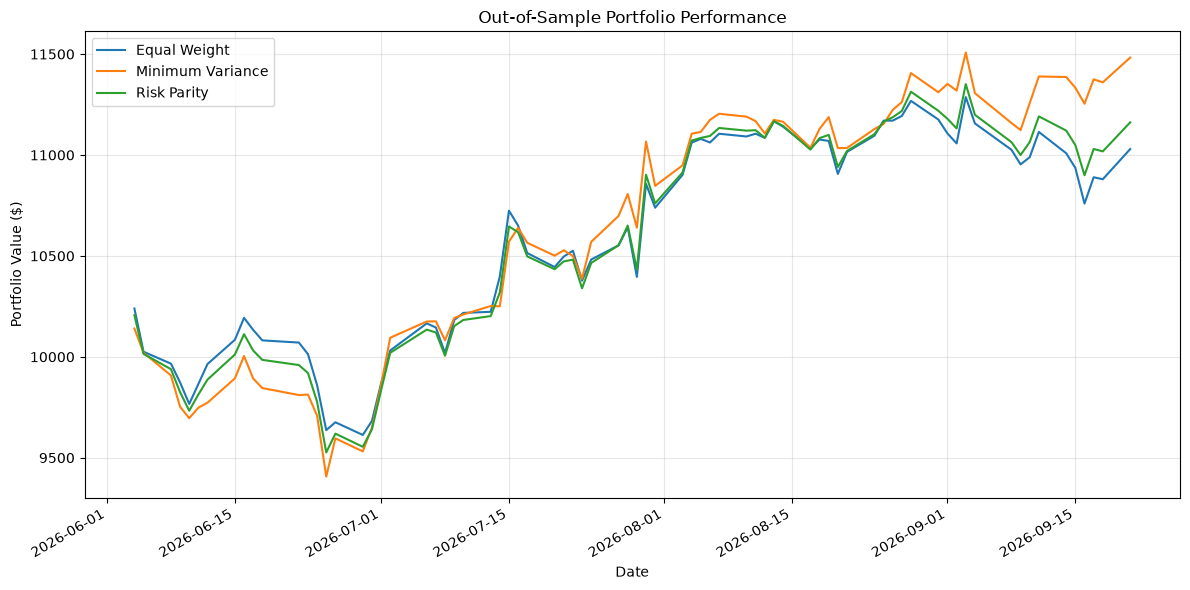

In [3]:

# Freeze portfolio weights determined from training data
portfolios = {
    "Equal Weight": equal_weights,
    "Minimum Variance": min_var_weights,
    "Risk Parity": rp_weights
}

# Apply fixed weights to the 75-day testing period.
# Daily rebalancing is assumed, with no transaction costs.
test_returns = pd.DataFrame(
    {
        name: test @ w
        for name, w in portfolios.items()
    },
    index=test.index
)

# Growth of $10,000 during the testing period
initial_capital = 10_000
growth = initial_capital * (1 + test_returns).cumprod()

# Calculate out-of-sample performance
def performance_metrics(r):
    total_return = (1 + r).prod() - 1
    annual_return = (1 + total_return) ** (252 / len(r)) - 1
    annual_volatility = r.std() * np.sqrt(252)

    # Sharpe ratio assumes a 0% risk-free rate
    sharpe = (
        r.mean() * 252 / annual_volatility
        if annual_volatility > 0 else np.nan
    )

    wealth = (1 + r).cumprod()
    running_peak = pd.concat(
        [pd.Series([1.0]), wealth.reset_index(drop=True)]
    ).cummax().iloc[1:].to_numpy()

    max_drawdown = (
        wealth.to_numpy() / running_peak - 1
    ).min()

    return pd.Series({
        "Total Return (%)": total_return * 100,
        "Annualized Return (%)": annual_return * 100,
        "Annualized Volatility (%)": annual_volatility * 100,
        "Sharpe Ratio": sharpe,
        "Maximum Drawdown (%)": max_drawdown * 100,
        "Final Value ($)": initial_capital * (1 + total_return)
    })

results = test_returns.apply(performance_metrics).T

print("OUT-OF-SAMPLE PERFORMANCE")
print("Testing period:", test.index.min().date(),
      "to", test.index.max().date())

display(results.round(2))

# Plot growth of $10,000
growth.plot(
    figsize=(12, 6),
    title="Out-of-Sample Portfolio Performance"
)

plt.ylabel("Portfolio Value ($)")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:

# Compare gross out-of-sample performance
display(results.round(2))

# Transaction-cost sensitivity:
# Daily rebalancing from the previous day's drifted weights.
cost_rates = [0, 0.0005, 0.001, 0.002]

def backtest_with_costs(asset_returns, target_weights, cost_rate):
    weights = np.asarray(target_weights, dtype=float)
    wealth = 10_000.0
    daily_net_returns = []

    for day_returns in asset_returns.to_numpy():
        # Portfolio return before rebalancing
        gross_return = weights @ day_returns
        wealth *= (1 + gross_return)

        # Weights drift after market movements
        drifted = weights * (1 + day_returns) / (1 + gross_return)

        # Rebalance to the original target weights
        # No final-day rebalance is needed
        turnover = np.abs(weights - drifted).sum()
        cost = cost_rate * turnover

        wealth *= (1 - cost)
        daily_net_returns.append(gross_return - cost * (1 + gross_return))

    return (1 + pd.Series(daily_net_returns)).prod() - 1

cost_results = pd.DataFrame({
    name: {
        f"{rate:.2%} cost": (
            backtest_with_costs(test, w, rate) * 100
        )
        for rate in cost_rates
    }
    for name, w in portfolios.items()
}).T

print("Out-of-sample total return after transaction costs (%):")
display(cost_results.round(2))

,Total Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Maximum Drawdown (%),Final Value ($)
Equal Weight,10.29,38.99,19.55,1.78,-6.12,11029.46
Minimum Variance,14.83,59.13,18.95,2.55,-7.24,11482.65
Risk Parity,11.62,44.67,19.17,2.02,-6.66,11161.79


Out-of-sample total return after transaction costs (%):


,0.00% cost,0.05% cost,0.10% cost,0.20% cost
Equal Weight,10.29,10.25,10.20,10.11
Minimum Variance,14.83,14.78,14.74,14.65
Risk Parity,11.62,11.57,11.52,11.43


# Day 12 — Out-of-Sample Portfolio Backtest

## Objective

Evaluate whether portfolio allocations estimated using historical training data remain effective on previously unseen market data.

## Methodology

Five stocks (AAPL, BLK, GS, JPM and MSFT) were divided chronologically into 174 training days and 75 testing days. Equal-weight, minimum-variance and risk-parity portfolios were constructed using training data only. Their allocations were then held as fixed targets during the testing period, assuming daily rebalancing.

## Results

| Portfolio        | Test return | Return at 0.20% transaction cost |
| ---------------- | ----------: | -------------------------------: |
| Equal Weight     |      10.29% |                           10.11% |
| Minimum Variance |      14.83% |                           14.65% |
| Risk Parity      |      11.62% |                           11.43% |

The minimum-variance portfolio delivered the highest total return in the observed testing period. Its annualized volatility was 18.95%, and its Sharpe ratio was 2.55.

## Investment Research Conclusion

The experiment demonstrates the importance of evaluating portfolio optimization using data excluded from the original estimation process. Minimum variance produced favorable results in this sample, but its historical performance does not establish persistent superiority.

Transaction costs reduced the returns of all three portfolios without changing their observed ordering in the tested scenarios.

## Limitations

The testing period was relatively short. The analysis assumes daily rebalancing and simplified proportional transaction costs. It excludes taxes, financing costs, liquidity constraints and market impact. Additional testing across different market regimes and longer out-of-sample periods is necessary.
